In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\jeevi\OneDrive\Desktop\BusinessCustomerIntelligence 1\Data\retail_customers.csv")

df.head()

ModuleNotFoundError: No module named 'pandas'

In [1]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd

print("Pandas is working!")
print(pd.__version__)

Pandas is working!
3.0.5


In [2]:
import pandas as pd

df = pd.read_csv("Data/retail_customers.csv")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Data/retail_customers.csv'

In [3]:
import os

print(os.getcwd())

C:\Users\jeevi\OneDrive\Desktop\BusinessCustomerIntelligence 1


In [4]:
import os

print(os.listdir("Data"))

['New Text Document.txt', 'retail_customers.csv 1.txt']


In [5]:
import os
print(os.listdir("Data"))

['retail_customers.csv 1.txt']


In [6]:

import os

print(os.listdir("Data"))

['retail_customers.csv 1.txt.txt']


In [7]:
import os
print(os.listdir("Data"))

['retail_customers.csv.txt']


In [8]:
import os
print(os.listdir("Data"))

['retail_customers.csv.txt']


In [9]:
import os
print(os.listdir("Data"))

['retail_customers.csv.txt']


In [10]:
import os

os.rename(
    "Data/retail_customers.csv.txt",
    "Data/retail_customers.csv"
)

print(os.listdir("Data"))

['retail_customers.csv']


In [11]:
import pandas as pd

df = pd.read_csv("Data/retail_customers.csv")

df.head()

,Customer_ID,Age,Annual_Income,Purchase_Frequency,Average_Order_Value,Total_Spending,Recency_Days
0,C001,23,25000,2,800,1600,45
1,C002,35,55000,8,2500,20000,5
2,C003,42,75000,12,3500,42000,3
3,C004,28,30000,3,900,2700,60
4,C005,51,90000,10,4200,42000,7


In [12]:
df.shape

(20, 7)

In [13]:
df.isnull().sum()

Customer_ID            0
Age                    0
Annual_Income          0
Purchase_Frequency     0
Average_Order_Value    0
Total_Spending         0
Recency_Days           0
dtype: int64

In [14]:
df["Customer_ID"].duplicated().sum()

np.int64(0)

In [15]:
df.shape

(20, 7)

In [16]:

df.describe()



,Age,Annual_Income,Purchase_Frequency,Average_Order_Value,Total_Spending,Recency_Days
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,38.050000,60350.000000,6.000000,2120.000000,16130.000000,36.200000
std,10.894108,25290.470433,3.494356,1151.932016,15440.892393,37.321646
min,22.000000,22000.000000,1.000000,600.000000,600.000000,3.000000
25%,28.750000,38000.000000,2.750000,1150.000000,3500.000000,7.750000
50%,37.500000,62500.000000,6.000000,1900.000000,9900.000000,17.500000
75%,46.500000,81250.000000,9.000000,2850.000000,26100.000000,63.750000
max,57.000000,100000.000000,12.000000,4500.000000,49500.000000,120.000000


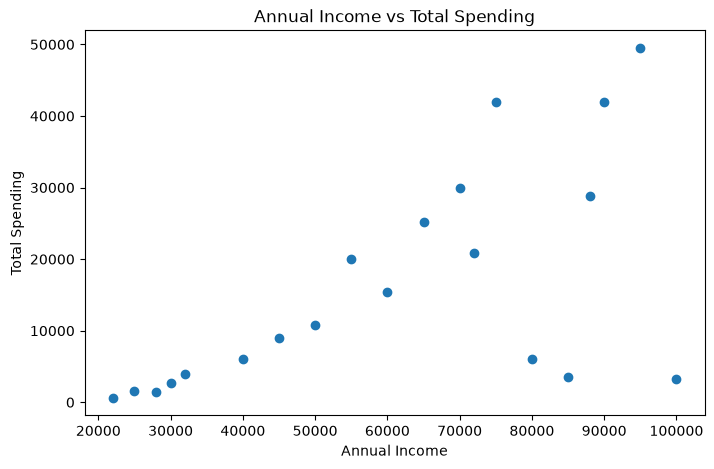

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(df["Annual_Income"], df["Total_Spending"])

plt.xlabel("Annual Income")
plt.ylabel("Total Spending")
plt.title("Annual Income vs Total Spending")

plt.show()

In [18]:
Age
Annual_Income
Purchase_Frequency
Average_Order_Value
Total_Spending
Recency_Days

NameError: name 'Age' is not defined

In [19]:
features = [
    "Age",
    "Annual_Income",
    "Purchase_Frequency",
    "Average_Order_Value",
    "Total_Spending",
    "Recency_Days"
]

X = df[features]

X.head()

,Age,Annual_Income,Purchase_Frequency,Average_Order_Value,Total_Spending,Recency_Days
0,23,25000,2,800,1600,45
1,35,55000,8,2500,20000,5
2,42,75000,12,3500,42000,3
3,28,30000,3,900,2700,60
4,51,90000,10,4200,42000,7


In [20]:
Age                  → 22–57
Annual Income        → 22000–100000
Purchase Frequency   → 1–12
Total Spending       → 600–49500

SyntaxError: invalid character '→' (U+2192) (3900500732.py, line 1)

In [21]:
features = [
    "Age",
    "Annual_Income",
    "Purchase_Frequency",
    "Average_Order_Value",
    "Total_Spending",
    "Recency_Days"
]

X = df[features]

X.head()

,Age,Annual_Income,Purchase_Frequency,Average_Order_Value,Total_Spending,Recency_Days
0,23,25000,2,800,1600,45
1,35,55000,8,2500,20000,5
2,42,75000,12,3500,42000,3
3,28,30000,3,900,2700,60
4,51,90000,10,4200,42000,7


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.41736936, -1.43407118, -1.17444044, -1.17566958, -0.96545362,
         0.24191349],
       [-0.28724097, -0.21703765,  0.58722022,  0.33845033,  0.25714422,
        -0.85769327],
       [ 0.3720006 ,  0.59431804,  1.76166066,  1.2291091 ,  1.71894598,
        -0.91267361],
       [-0.94648253, -1.23123226, -0.88083033, -1.0866037 , -0.89236353,
         0.65426602],
       [ 1.21959689,  1.20283481,  1.17444044,  1.85257024,  1.71894598,
        -0.80271293]])

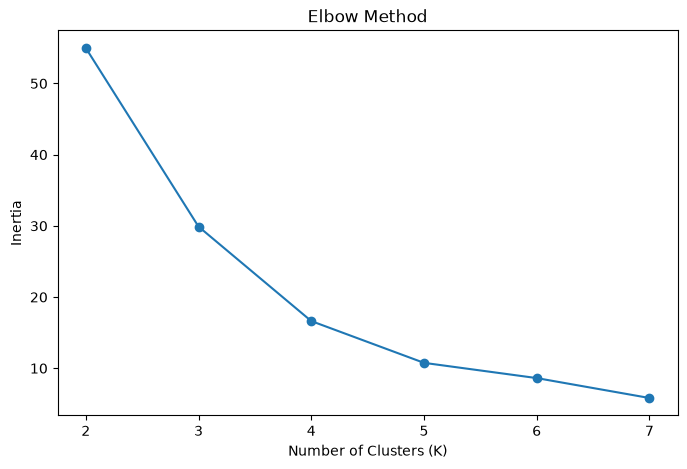

In [23]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 8), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f"K = {k}, Silhouette Score = {score:.3f}")

K = 2, Silhouette Score = 0.441
K = 3, Silhouette Score = 0.535
K = 4, Silhouette Score = 0.482
K = 5, Silhouette Score = 0.456
K = 6, Silhouette Score = 0.407


In [25]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,Customer_ID,Age,Annual_Income,Purchase_Frequency,Average_Order_Value,Total_Spending,Recency_Days,Cluster
0,C001,23,25000,2,800,1600,45,1
1,C002,35,55000,8,2500,20000,5,0
2,C003,42,75000,12,3500,42000,3,0
3,C004,28,30000,3,900,2700,60,1
4,C005,51,90000,10,4200,42000,7,0


In [26]:
cluster_summary = df.groupby("Cluster")[[
    "Age",
    "Annual_Income",
    "Purchase_Frequency",
    "Average_Order_Value",
    "Total_Spending",
    "Recency_Days"
]].mean().round(2)

cluster_summary

,Age,Annual_Income,Purchase_Frequency,Average_Order_Value,Total_Spending,Recency_Days
Cluster,,,,,,
0,43.67,74444.44,9.33,3166.67,30411.11,7.11
1,27.12,34000.00,3.62,1062.50,4512.50,48.75
2,50.33,88333.33,2.33,1800.00,4266.67,90.00


In [27]:
cluster_names = {
    0: "High-Value Customers",
    1: "Low-Value / Inactive Customers",
    2: "High-Income At-Risk Customers"
}

df["Segment"] = df["Cluster"].map(cluster_names)

df[["Customer_ID", "Cluster", "Segment"]]

,Customer_ID,Cluster,Segment
0,C001,1,Low-Value / Inactive Customers
1,C002,0,High-Value Customers
2,C003,0,High-Value Customers
3,C004,1,Low-Value / Inactive Customers
4,C005,0,High-Value Customers
5,C006,2,High-Income At-Risk Customers
6,C007,1,Low-Value / Inactive Customers
7,C008,0,High-Value Customers
8,C009,1,Low-Value / Inactive Customers
9,C010,0,High-Value Customers


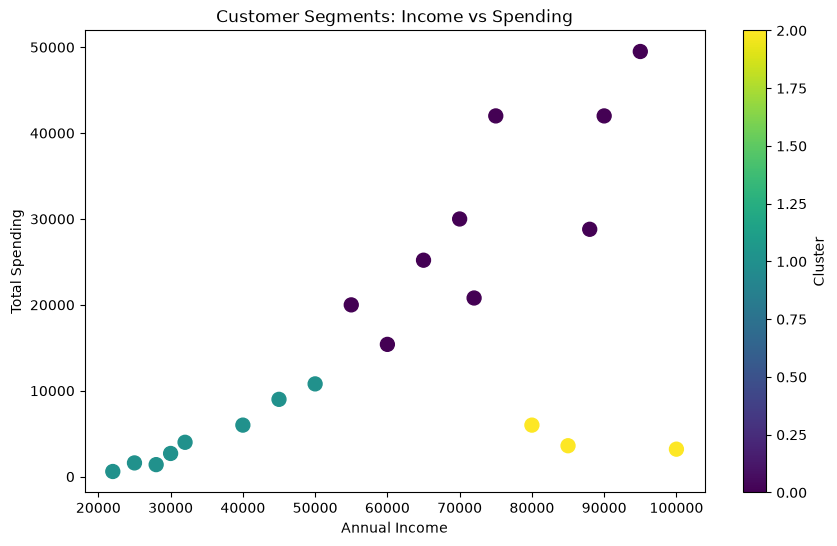

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Annual_Income"],
    df["Total_Spending"],
    c=df["Cluster"],
    s=100
)

plt.xlabel("Annual Income")
plt.ylabel("Total Spending")
plt.title("Customer Segments: Income vs Spending")
plt.colorbar(label="Cluster")

plt.show()

In [29]:
segment_counts = df["Segment"].value_counts()

segment_counts

Segment
High-Value Customers              9
Low-Value / Inactive Customers    8
High-Income At-Risk Customers     3
Name: count, dtype: int64

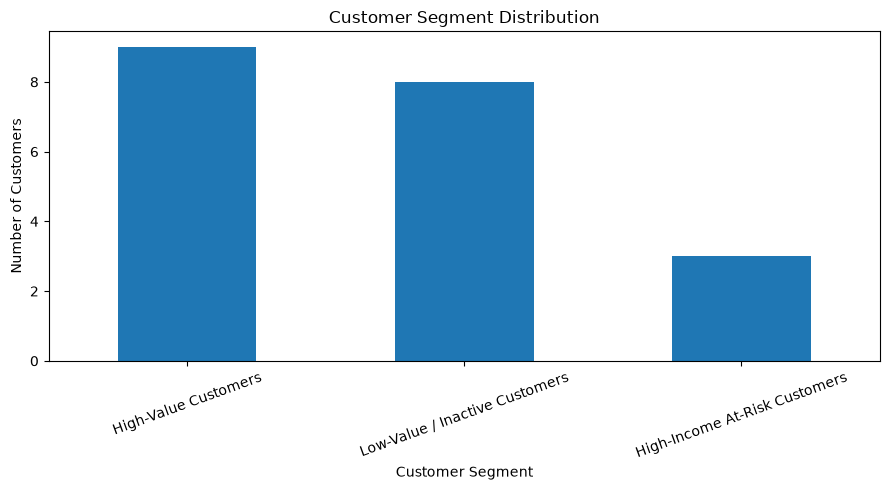

In [30]:
plt.figure(figsize=(9, 5))

segment_counts.plot(kind="bar")

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.title("Customer Segment Distribution")

plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

In [31]:
recommendations = {
    "High-Value Customers":
        "Offer loyalty rewards, premium products, early access to new products, and personalized recommendations.",

    "Low-Value / Inactive Customers":
        "Send re-engagement campaigns, discounts, limited-time offers, and personalized product suggestions.",

    "High-Income At-Risk Customers":
        "Use premium re-engagement offers, personalized recommendations, exclusive benefits, and targeted retention campaigns."
}

df["Recommendation"] = df["Segment"].map(recommendations)

df[[
    "Customer_ID",
    "Segment",
    "Recommendation"
]]

,Customer_ID,Segment,Recommendation
0,C001,Low-Value / Inactive Customers,"Send re-engagement campaigns, discounts, limit..."
1,C002,High-Value Customers,"Offer loyalty rewards, premium products, early..."
2,C003,High-Value Customers,"Offer loyalty rewards, premium products, early..."
3,C004,Low-Value / Inactive Customers,"Send re-engagement campaigns, discounts, limit..."
4,C005,High-Value Customers,"Offer loyalty rewards, premium products, early..."
5,C006,High-Income At-Risk Customers,"Use premium re-engagement offers, personalized..."
6,C007,Low-Value / Inactive Customers,"Send re-engagement campaigns, discounts, limit..."
7,C008,High-Value Customers,"Offer loyalty rewards, premium products, early..."
8,C009,Low-Value / Inactive Customers,"Send re-engagement campaigns, discounts, limit..."
9,C010,High-Value Customers,"Offer loyalty rewards, premium products, early..."


In [32]:
customer_intelligence = df[[
    "Customer_ID",
    "Age",
    "Annual_Income",
    "Purchase_Frequency",
    "Average_Order_Value",
    "Total_Spending",
    "Recency_Days",
    "Segment",
    "Recommendation"
]]

customer_intelligence

,Customer_ID,Age,Annual_Income,Purchase_Frequency,Average_Order_Value,Total_Spending,Recency_Days,Segment,Recommendation
0,C001,23,25000,2,800,1600,45,Low-Value / Inactive Customers,"Send re-engagement campaigns, discounts, limit..."
1,C002,35,55000,8,2500,20000,5,High-Value Customers,"Offer loyalty rewards, premium products, early..."
2,C003,42,75000,12,3500,42000,3,High-Value Customers,"Offer loyalty rewards, premium products, early..."
3,C004,28,30000,3,900,2700,60,Low-Value / Inactive Customers,"Send re-engagement campaigns, discounts, limit..."
4,C005,51,90000,10,4200,42000,7,High-Value Customers,"Offer loyalty rewards, premium products, early..."
5,C006,46,85000,2,1800,3600,90,High-Income At-Risk Customers,"Use premium re-engagement offers, personalized..."
6,C007,31,45000,6,1500,9000,15,Low-Value / Inactive Customers,"Send re-engagement campaigns, discounts, limit..."
7,C008,39,65000,9,2800,25200,8,High-Value Customers,"Offer loyalty rewards, premium products, early..."
8,C009,24,28000,2,700,1400,75,Low-Value / Inactive Customers,"Send re-engagement campaigns, discounts, limit..."
9,C010,55,95000,11,4500,49500,4,High-Value Customers,"Offer loyalty rewards, premium products, early..."


In [33]:
high_value_customers = df[
    df["Segment"] == "High-Value Customers"
]

high_value_customers[[
    "Customer_ID",
    "Annual_Income",
    "Purchase_Frequency",
    "Total_Spending",
    "Recency_Days"
]]

,Customer_ID,Annual_Income,Purchase_Frequency,Total_Spending,Recency_Days
1,C002,55000,8,20000,5
2,C003,75000,12,42000,3
4,C005,90000,10,42000,7
7,C008,65000,9,25200,8
9,C010,95000,11,49500,4
12,C013,60000,7,15400,12
14,C015,70000,10,30000,6
18,C019,72000,8,20800,10
19,C020,88000,9,28800,9


In [34]:
at_risk_customers = df[
    df["Segment"] == "High-Income At-Risk Customers"
]

at_risk_customers[[
    "Customer_ID",
    "Annual_Income",
    "Purchase_Frequency",
    "Total_Spending",
    "Recency_Days"
]]

,Customer_ID,Annual_Income,Purchase_Frequency,Total_Spending,Recency_Days
5,C006,85000,2,3600,90
11,C012,80000,3,6000,85
16,C017,100000,2,3200,95


In [35]:
def get_business_summary():
    total_customers = len(df)
    total_revenue = df["Total_Spending"].sum()
    average_spending = df["Total_Spending"].mean()

    return {
        "total_customers": total_customers,
        "total_spending": total_revenue,
        "average_spending": average_spending
    }


summary = get_business_summary()

summary

{'total_customers': 20,
 'total_spending': np.int64(322600),
 'average_spending': np.float64(16130.0)}

In [36]:
def get_segment_analysis(segment_name):

    segment_data = df[df["Segment"] == segment_name]

    if len(segment_data) == 0:
        return "Segment not found."

    return {
        "customer_count": len(segment_data),
        "average_income": segment_data["Annual_Income"].mean(),
        "average_spending": segment_data["Total_Spending"].mean(),
        "average_purchase_frequency": segment_data["Purchase_Frequency"].mean(),
        "average_recency": segment_data["Recency_Days"].mean()
    }

In [37]:
get_segment_analysis("High-Value Customers")

{'customer_count': 9,
 'average_income': np.float64(74444.44444444444),
 'average_spending': np.float64(30411.11111111111),
 'average_purchase_frequency': np.float64(9.333333333333334),
 'average_recency': np.float64(7.111111111111111)}

In [38]:
def business_assistant(question):

    question = question.lower()

    if "how many customers" in question:
        return f"There are {len(df)} customers in the dataset."

    elif "high-value" in question or "high value" in question:
        count = (df["Segment"] == "High-Value Customers").sum()
        return f"There are {count} High-Value Customers."

    elif "at-risk" in question or "at risk" in question:
        count = (df["Segment"] == "High-Income At-Risk Customers").sum()
        return f"There are {count} High-Income At-Risk Customers."

    elif "inactive" in question or "low-value" in question:
        count = (df["Segment"] == "Low-Value / Inactive Customers").sum()
        return f"There are {count} Low-Value / Inactive Customers."

    elif "highest spending" in question or "spends the most" in question:
        highest_segment = (
            df.groupby("Segment")["Total_Spending"]
            .mean()
            .idxmax()
        )
        return f"{highest_segment} have the highest average spending."

    else:
        return (
            "I can answer questions about customers, "
            "segments, spending, and business recommendations."
        )

In [39]:
business_assistant("How many high-value customers do we have?")

'There are 9 High-Value Customers.'

In [40]:
business_assistant("Which segment has the highest spending?")

'High-Value Customers have the highest average spending.'

In [41]:
business_assistant("How many customers are at risk?")

'There are 20 customers in the dataset.'

In [42]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# -----------------------------
# PAGE CONFIGURATION
# -----------------------------

st.set_page_config(
    page_title="Business Customer Intelligence",
    page_icon="📊",
    layout="wide"
)


# -----------------------------
# LOAD DATA
# -----------------------------

@st.cache_data
def load_data():

    df = pd.read_csv("Data/retail_customers.csv")

    return df


df = load_data()


# -----------------------------
# MACHINE LEARNING
# -----------------------------

features = [
    "Age",
    "Annual_Income",
    "Purchase_Frequency",
    "Average_Order_Value",
    "Total_Spending",
    "Recency_Days"
]

X = df[features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)


# -----------------------------
# CUSTOMER SEGMENT NAMES
# -----------------------------

cluster_names = {
    0: "High-Value Customers",
    1: "Low-Value / Inactive Customers",
    2: "High-Income At-Risk Customers"
}

df["Segment"] = df["Cluster"].map(cluster_names)


# -----------------------------
# RECOMMENDATIONS
# -----------------------------

recommendations = {
    "High-Value Customers":
        "Offer loyalty rewards, premium products, early access and personalized recommendations.",

    "Low-Value / Inactive Customers":
        "Send re-engagement campaigns, discounts and personalized product suggestions.",

    "High-Income At-Risk Customers":
        "Use premium re-engagement offers, exclusive benefits and targeted retention campaigns."
}

df["Recommendation"] = df["Segment"].map(recommendations)


# -----------------------------
# TITLE
# -----------------------------

st.title("📊 Business Customer Intelligence Platform")

st.write(
    "AI-powered customer segmentation and business insights using Machine Learning."
)


# -----------------------------
# DASHBOARD METRICS
# -----------------------------

col1, col2, col3, col4 = st.columns(4)

col1.metric(
    "Total Customers",
    len(df)
)

col2.metric(
    "Total Spending",
    f"₹{df['Total_Spending'].sum():,.0f}"
)

col3.metric(
    "Average Spending",
    f"₹{df['Total_Spending'].mean():,.0f}"
)

col4.metric(
    "Customer Segments",
    df["Segment"].nunique()
)


# -----------------------------
# SEGMENT DISTRIBUTION
# -----------------------------

st.header("👥 Customer Segments")

segment_counts = df["Segment"].value_counts()

st.bar_chart(segment_counts)


# -----------------------------
# INCOME VS SPENDING
# -----------------------------

st.header("📈 Income vs Spending")

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(
    df["Annual_Income"],
    df["Total_Spending"],
    c=df["Cluster"],
    s=100
)

ax.set_xlabel("Annual Income")
ax.set_ylabel("Total Spending")
ax.set_title("Customer Segmentation")

st.pyplot(fig)


# -----------------------------
# CUSTOMER TABLE
# -----------------------------

st.header("📋 Customer Intelligence")

st.dataframe(
    df[
        [
            "Customer_ID",
            "Age",
            "Annual_Income",
            "Purchase_Frequency",
            "Average_Order_Value",
            "Total_Spending",
            "Recency_Days",
            "Segment",
            "Recommendation"
        ]
    ],
    use_container_width=True
)


# -----------------------------
# CUSTOMER SEARCH
# -----------------------------

st.header("🔍 Customer Search")

customer_id = st.text_input(
    "Enter Customer ID",
    placeholder="Example: C005"
)

if customer_id:

    customer = df[
        df["Customer_ID"].str.upper() == customer_id.upper()
    ]

    if len(customer) == 0:

        st.warning("Customer not found.")

    else:

        customer = customer.iloc[0]

        st.success(
            f"Customer {customer['Customer_ID']} belongs to "
            f"{customer['Segment']}."
        )

        st.write("### Customer Details")

        st.write(
            f"**Age:** {customer['Age']}"
        )

        st.write(
            f"**Annual Income:** ₹{customer['Annual_Income']:,.0f}"
        )

        st.write(
            f"**Purchase Frequency:** {customer['Purchase_Frequency']}"
        )

        st.write(
            f"**Average Order Value:** ₹{customer['Average_Order_Value']:,.0f}"
        )

        st.write(
            f"**Total Spending:** ₹{customer['Total_Spending']:,.0f}"
        )

        st.write(
            f"**Recency:** {customer['Recency_Days']} days"
        )

        st.info(
            f"💡 Recommendation: {customer['Recommendation']}"
        )


# -----------------------------
# BUSINESS ASSISTANT
# -----------------------------

st.header("🤖 Business Intelligence Assistant")

question = st.text_input(
    "Ask a question about your customers",
    placeholder="Example: How many high-value customers do we have?"
)


if question:

    question = question.lower()

    if "high-value" in question or "high value" in question:

        count = (
            df["Segment"] == "High-Value Customers"
        ).sum()

        st.success(
            f"There are {count} High-Value Customers."
        )

    elif "at-risk" in question or "at risk" in question:

        count = (
            df["Segment"] ==
            "High-Income At-Risk Customers"
        ).sum()

        st.warning(
            f"There are {count} High-Income At-Risk Customers."
        )

    elif "inactive" in question or "low-value" in question:

        count = (
            df["Segment"] ==
            "Low-Value / Inactive Customers"
        ).sum()

        st.info(
            f"There are {count} Low-Value / Inactive Customers."
        )

    elif "highest spending" in question or "spends the most" in question:

        highest_segment = (
            df.groupby("Segment")["Total_Spending"]
            .mean()
            .idxmax()
        )

        st.success(
            f"{highest_segment} have the highest average spending."
        )

    elif "how many customers" in question:

        st.success(
            f"There are {len(df)} customers in the dataset."
        )

    else:

        st.info(
            "I can answer questions about customers, "
            "segments, spending and business recommendations."
        )

ModuleNotFoundError: No module named 'streamlit'

In [43]:
%pip install streamlit

  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached watchdog-6.0.0-py3-none-win_amd64.whl.metadata (44 kB)
   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/10.5 MB 6.8 MB/s eta 0:00:02
   --------- ------------------------------ 2.6/10.5 MB 6.6 MB/s eta 0:00:02
   ---------------- ----------------------- 4.5/10.5 MB 7.5 MB/s eta 0:00:01
   ---------------------- ----------------- 6.0/10.5 MB 7.3 MB/s eta 0:00:01
   ---------------------------- ----------- 7.6/10.5 MB 7.5 MB/s eta 0:00:01
   --------------------------------- ------ 8.9/10.5 MB 7.1 MB/s eta 0:00:01
   ---------------------------------------  10.5/10.5 MB 7.2 MB/s eta 0:00:01
   ---------------------------------------- 10.5/10.5 MB 7.0 MB/s  0:00:01
   ---------------------------------------- 0.0/797.6 kB ? eta -:--:--
   ------------------------------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import streamlit as st

print("Streamlit is working!")

Streamlit is working!


In [2]:
cd "C:\Users\jeevi\OneDrive\Desktop\BusinessCustomerIntelligence 1"

C:\Users\jeevi\OneDrive\Desktop\BusinessCustomerIntelligence 1


In [3]:
cd "C:\Users\jeevi\OneDrive\Desktop\BusinessCustomerIntelligence 1"

C:\Users\jeevi\OneDrive\Desktop\BusinessCustomerIntelligence 1


In [4]:
dir

<function dir>